<a href="https://colab.research.google.com/github/arxsyy/MachineLearning_2026/blob/main/JS06_Tugas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Klasifikasi Dataset voice.csv Menggunakan SVM**

In [2]:
# Import library untuk pengolahan data
import pandas as pd
import numpy as np

# Import library untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Membaca dataset voice.csv
df = pd.read_csv('/content/voice.csv')

# Menampilkan 5 data pertama
df.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [3]:
# Menampilkan dimensi dataset
print("Dimensi dataset:", df.shape)

# Menampilkan informasi tipe data setiap kolom
df.info()

# Mengecek missing value
print("\nJumlah missing value:")
print(df.isnull().sum())

# Mengecek jumlah data setiap kelas
print("\nJumlah data per kelas:")
print(df['label'].value_counts())

Dimensi dataset: (3168, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meanfreq  3168 non-null   float64
 1   sd        3168 non-null   float64
 2   median    3168 non-null   float64
 3   Q25       3168 non-null   float64
 4   Q75       3168 non-null   float64
 5   IQR       3168 non-null   float64
 6   skew      3168 non-null   float64
 7   kurt      3168 non-null   float64
 8   sp.ent    3168 non-null   float64
 9   sfm       3168 non-null   float64
 10  mode      3168 non-null   float64
 11  centroid  3168 non-null   float64
 12  meanfun   3168 non-null   float64
 13  minfun    3168 non-null   float64
 14  maxfun    3168 non-null   float64
 15  meandom   3168 non-null   float64
 16  mindom    3168 non-null   float64
 17  maxdom    3168 non-null   float64
 18  dfrange   3168 non-null   float64
 19  modindx   3168 non-null   float64
 20  la

In [4]:
# Memisahkan fitur dan target
X = df.drop('label', axis=1)
y = df['label']

# Menampilkan dimensi fitur dan target
print("Dimensi X:", X.shape)
print("Dimensi y:", y.shape)

Dimensi X: (3168, 20)
Dimensi y: (3168,)


In [5]:
# Import fungsi pembagian data
from sklearn.model_selection import train_test_split

# Import StandardScaler untuk normalisasi data
from sklearn.preprocessing import StandardScaler

# Import Support Vector Machine
from sklearn.svm import SVC

# Import metrik evaluasi
from sklearn.metrics import accuracy_score

In [6]:
# Fungsi untuk melatih dan mengevaluasi model SVM
def evaluasi_svm(test_size, kernel_name):

    # Membagi data training dan testing
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=42,
        stratify=y
    )

    # Membuat StandardScaler
    scaler = StandardScaler()

    # Scaling data training
    X_train_scaled = scaler.fit_transform(X_train)

    # Scaling data testing menggunakan parameter training
    X_test_scaled = scaler.transform(X_test)

    # Membuat model SVM sesuai kernel
    model = SVC(
        kernel=kernel_name,
        random_state=42
    )

    # Melatih model
    model.fit(X_train_scaled, y_train)

    # Melakukan prediksi
    y_pred = model.predict(X_test_scaled)

    # Menghitung akurasi
    acc = accuracy_score(y_test, y_pred)

    return acc

**2. Percobaan SVM dengan Split 70:30**

In [7]:
# SVM kernel linear dengan split 70:30
acc_70_linear = evaluasi_svm(
    test_size=0.3,
    kernel_name='linear'
)

print("Akurasi SVM Linear 70:30:", acc_70_linear)

Akurasi SVM Linear 70:30: 0.9789695057833859


In [8]:
# SVM kernel polynomial dengan split 70:30
acc_70_poly = evaluasi_svm(
    test_size=0.3,
    kernel_name='poly'
)

print("Akurasi SVM Polynomial 70:30:", acc_70_poly)

Akurasi SVM Polynomial 70:30: 0.9600420609884333


In [9]:
# SVM kernel RBF dengan split 70:30
acc_70_rbf = evaluasi_svm(
    test_size=0.3,
    kernel_name='rbf'
)

print("Akurasi SVM RBF 70:30:", acc_70_rbf)

Akurasi SVM RBF 70:30: 0.9831756046267087


**3. Percobaan SVM dengan Split 80:20**

In [10]:
# SVM kernel linear dengan split 80:20
acc_80_linear = evaluasi_svm(
    test_size=0.2,
    kernel_name='linear'
)

print("Akurasi SVM Linear 80:20:", acc_80_linear)

Akurasi SVM Linear 80:20: 0.9747634069400631


In [11]:
# SVM kernel polynomial dengan split 80:20
acc_80_poly = evaluasi_svm(
    test_size=0.2,
    kernel_name='poly'
)

print("Akurasi SVM Polynomial 80:20:", acc_80_poly)

Akurasi SVM Polynomial 80:20: 0.9558359621451105


In [12]:
# SVM kernel RBF dengan split 80:20
acc_80_rbf = evaluasi_svm(
    test_size=0.2,
    kernel_name='rbf'
)

print("Akurasi SVM RBF 80:20:", acc_80_rbf)

Akurasi SVM RBF 80:20: 0.9826498422712934


**Tabulasi Performa Semua Model**

In [13]:
# Membuat tabel hasil akurasi seluruh percobaan
hasil_svm = pd.DataFrame({
    'Split Data': [
        '70:30',
        '70:30',
        '70:30',
        '80:20',
        '80:20',
        '80:20'
    ],

    'Kernel': [
        'Linear',
        'Polynomial',
        'RBF',
        'Linear',
        'Polynomial',
        'RBF'
    ],

    'Akurasi': [
        acc_70_linear,
        acc_70_poly,
        acc_70_rbf,
        acc_80_linear,
        acc_80_poly,
        acc_80_rbf
    ]
})

hasil_svm

,Split Data,Kernel,Akurasi
0,70:30,Linear,0.978970
1,70:30,Polynomial,0.960042
2,70:30,RBF,0.983176
3,80:20,Linear,0.974763
4,80:20,Polynomial,0.955836
5,80:20,RBF,0.982650


In [14]:
# Membuat salinan tabel untuk tampilan persen
hasil_tampil = hasil_svm.copy()

hasil_tampil['Akurasi (%)'] = (
    hasil_tampil['Akurasi'] * 100
).round(2)

hasil_tampil[
    ['Split Data', 'Kernel', 'Akurasi (%)']
]

,Split Data,Kernel,Akurasi (%)
0,70:30,Linear,97.90
1,70:30,Polynomial,96.00
2,70:30,RBF,98.32
3,80:20,Linear,97.48
4,80:20,Polynomial,95.58
5,80:20,RBF,98.26


In [15]:
# Mencari model dengan akurasi tertinggi
model_terbaik = hasil_svm.loc[
    hasil_svm['Akurasi'].idxmax()
]

print("Model terbaik:")
print("Split Data :", model_terbaik['Split Data'])
print("Kernel     :", model_terbaik['Kernel'])
print("Akurasi    :", model_terbaik['Akurasi'])

Model terbaik:
Split Data : 70:30
Kernel     : RBF
Akurasi    : 0.9831756046267087


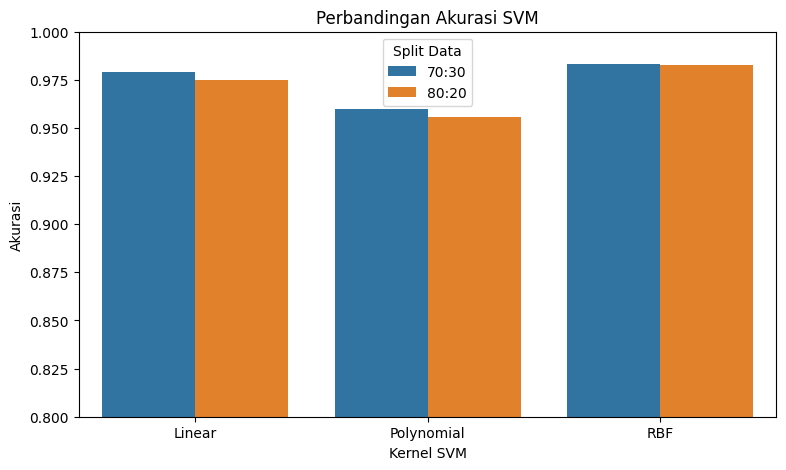

In [16]:
# Membuat grafik perbandingan akurasi
plt.figure(figsize=(9, 5))

sns.barplot(
    data=hasil_svm,
    x='Kernel',
    y='Akurasi',
    hue='Split Data'
)

plt.title('Perbandingan Akurasi SVM')
plt.xlabel('Kernel SVM')
plt.ylabel('Akurasi')
plt.ylim(0.8, 1.0)

plt.show()

Berdasarkan hasil pengujian, enam model SVM telah diuji menggunakan dua rasio pembagian data, yaitu 70:30 dan 80:20, serta tiga jenis kernel, yaitu linear, polynomial, dan RBF. Seluruh fitur terlebih dahulu distandardisasi menggunakan StandardScaler agar perbedaan skala antarfitur tidak memengaruhi perhitungan model SVM.
Hasil pengujian menunjukkan adanya perbedaan akurasi antara setiap kernel dan rasio pembagian data. Model terbaik ditentukan berdasarkan nilai akurasi tertinggi pada data testing. Perbedaan hasil ini menunjukkan bahwa pemilihan kernel dan jumlah data training dapat memengaruhi kemampuan SVM dalam mengklasifikasikan suara male dan female.

**2. Klasifikasi Siang dan Malam dengan SVM RBF**

In [23]:
# Import library dasar
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import library machine learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Import metrik evaluasi
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [21]:
# Ekstrak file images.zip ke folder /content
!unzip /content/images.zip -d /content/

Archive:  /content/images.zip
   creating: /content/images/
  inflating: /content/__MACOSX/._images  
   creating: /content/images/test/
  inflating: /content/__MACOSX/images/._test  
   creating: /content/images/training/
  inflating: /content/__MACOSX/images/._training  
   creating: /content/images/test/day/
  inflating: /content/__MACOSX/images/test/._day  
   creating: /content/images/test/night/
  inflating: /content/__MACOSX/images/test/._night  
   creating: /content/images/training/day/
  inflating: /content/__MACOSX/images/training/._day  
   creating: /content/images/training/night/
  inflating: /content/__MACOSX/images/training/._night  
  inflating: /content/images/test/day/20151102_122322.jpg  
  inflating: /content/__MACOSX/images/test/day/._20151102_122322.jpg  
  inflating: /content/images/test/day/20151101_235039.jpg  
  inflating: /content/__MACOSX/images/test/day/._20151101_235039.jpg  
  inflating: /content/images/test/day/20151102_114041.jpg  
  inflating: /conten

In [22]:
# Cek struktur folder hasil ekstrak
!find /content/images -maxdepth 2 -type d

/content/images
/content/images/training
/content/images/training/day
/content/images/training/night
/content/images/test
/content/images/test/day
/content/images/test/night


In [24]:
# Lokasi dataset
base_path = '/content/images'

# Folder training dan test bawaan dataset
train_path = os.path.join(base_path, 'training')
test_path = os.path.join(base_path, 'test')

print("Training path:", train_path)
print("Test path    :", test_path)

Training path: /content/images/training
Test path    : /content/images/test


In [25]:
# Fungsi untuk mengambil histogram grayscale dari sebuah citra
def extract_histogram(image_path):

    # Membaca gambar dalam mode grayscale
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Jika gambar gagal dibaca
    if image is None:
        return None

    # Menghitung histogram grayscale sebanyak 256 bin
    hist = cv2.calcHist(
        [image],
        [0],
        None,
        [256],
        [0, 256]
    )

    # Normalisasi histogram
    hist = cv2.normalize(hist, hist)

    # Mengubah histogram menjadi array 1 dimensi
    hist = hist.flatten()

    return hist

In [26]:
# Menyimpan fitur dan label
X = []
y = []

# Daftar kelas
classes = ['day', 'night']

# Daftar folder sumber
source_folders = [
    train_path,
    test_path
]

# Membaca semua gambar
for source in source_folders:

    for label in classes:

        class_path = os.path.join(source, label)

        # Loop semua file pada folder kelas
        for filename in os.listdir(class_path):

            image_path = os.path.join(class_path, filename)

            # Ekstraksi histogram
            feature = extract_histogram(image_path)

            # Simpan jika gambar berhasil dibaca
            if feature is not None:
                X.append(feature)
                y.append(label)

# Mengubah menjadi numpy array
X = np.array(X)
y = np.array(y)

print("Dimensi fitur:", X.shape)
print("Dimensi label:", y.shape)

Dimensi fitur: (400, 256)
Dimensi label: (400,)


In [27]:
# Menghitung jumlah data setiap kelas
unique, counts = np.unique(y, return_counts=True)

print("Jumlah data per kelas:")

for label, count in zip(unique, counts):
    print(label, ":", count)

Jumlah data per kelas:
day : 200
night : 200


In [28]:
# Membagi dataset menjadi 80% training dan 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Menampilkan dimensi hasil split
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (320, 256)
X_test : (80, 256)
y_train: (320,)
y_test : (80,)


In [29]:
# Membuat StandardScaler
scaler = StandardScaler()

# Scaling data training
X_train_scaled = scaler.fit_transform(X_train)

# Scaling data testing
X_test_scaled = scaler.transform(X_test)

In [30]:
# Membuat model SVM kernel RBF
svm_rbf = SVC(
    kernel='rbf',
    random_state=42
)

# Melatih model
svm_rbf.fit(X_train_scaled, y_train)

# Melakukan prediksi
y_pred_awal = svm_rbf.predict(X_test_scaled)

# Menghitung akurasi
accuracy_awal = accuracy_score(
    y_test,
    y_pred_awal
)

print("Akurasi SVM RBF sebelum tuning:", accuracy_awal)

Akurasi SVM RBF sebelum tuning: 0.975


In [31]:
# Menampilkan classification report
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_awal
    )
)

Classification Report:
              precision    recall  f1-score   support

         day       0.97      0.97      0.97        40
       night       0.97      0.97      0.97        40

    accuracy                           0.97        80
   macro avg       0.97      0.97      0.97        80
weighted avg       0.97      0.97      0.97        80



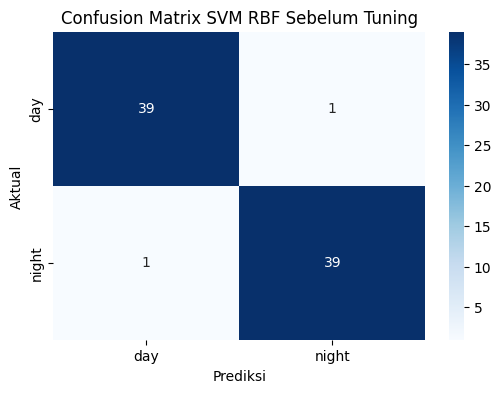

In [32]:
# Membuat confusion matrix
cm_awal = confusion_matrix(
    y_test,
    y_pred_awal,
    labels=['day', 'night']
)

# Visualisasi confusion matrix
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_awal,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['day', 'night'],
    yticklabels=['day', 'night']
)

plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix SVM RBF Sebelum Tuning')

plt.show()

In [33]:
# Menentukan kombinasi parameter yang akan diuji
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [
        'scale',
        'auto',
        0.001,
        0.01,
        0.1,
        1
    ]
}

# Membuat GridSearchCV
grid_search = GridSearchCV(
    estimator=SVC(kernel='rbf'),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Mencari parameter terbaik
grid_search.fit(
    X_train_scaled,
    y_train
)

GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100],
                         'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]},
             scoring='accuracy')

In [34]:
# Menampilkan parameter terbaik
print("Parameter terbaik:")
print(grid_search.best_params_)

# Menampilkan skor cross-validation terbaik
print("Akurasi CV terbaik:")
print(grid_search.best_score_)

Parameter terbaik:
{'C': 1, 'gamma': 0.01}
Akurasi CV terbaik:
0.9875


In [35]:
# Mengambil model terbaik hasil tuning
best_model = grid_search.best_estimator_

# Melakukan prediksi
y_pred_tuned = best_model.predict(
    X_test_scaled
)

# Menghitung akurasi
accuracy_tuned = accuracy_score(
    y_test,
    y_pred_tuned
)

print("Akurasi sebelum tuning :", accuracy_awal)
print("Akurasi setelah tuning :", accuracy_tuned)

Akurasi sebelum tuning : 0.975
Akurasi setelah tuning : 0.9875


In [36]:
# Menampilkan classification report
print(
    classification_report(
        y_test,
        y_pred_tuned
    )
)

              precision    recall  f1-score   support

         day       0.98      1.00      0.99        40
       night       1.00      0.97      0.99        40

    accuracy                           0.99        80
   macro avg       0.99      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



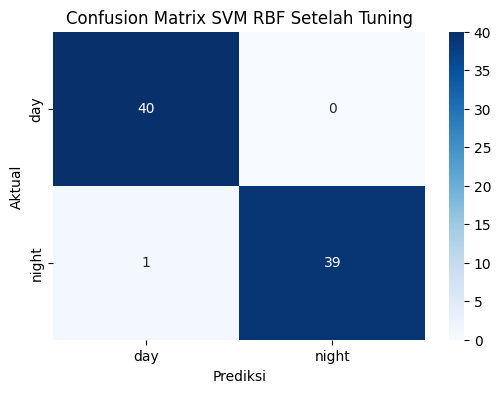

In [37]:
# Membuat confusion matrix hasil tuning
cm_tuned = confusion_matrix(
    y_test,
    y_pred_tuned,
    labels=['day', 'night']
)

# Visualisasi confusion matrix
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_tuned,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['day', 'night'],
    yticklabels=['day', 'night']
)

plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix SVM RBF Setelah Tuning')

plt.show()

In [38]:
# Membuat tabel perbandingan
hasil_perbandingan = pd.DataFrame({
    'Model': [
        'SVM RBF Default',
        'SVM RBF Tuning'
    ],
    'Akurasi': [
        accuracy_awal,
        accuracy_tuned
    ]
})

# Mengubah akurasi menjadi persen
hasil_perbandingan['Akurasi (%)'] = (
    hasil_perbandingan['Akurasi'] * 100
).round(2)

hasil_perbandingan

,Model,Akurasi,Akurasi (%)
0,SVM RBF Default,0.9750,97.50
1,SVM RBF Tuning,0.9875,98.75


Analisis performansi:
Model SVM kernel RBF digunakan untuk klasifikasi citra siang dan malam dengan fitur histogram. Performa dibandingkan berdasarkan akurasi sebelum dan sesudah hyperparameter tuning. Model dengan nilai akurasi lebih tinggi dianggap memiliki performa yang lebih baik.